# Fair-RAG LaMP-4 Reproduction (Minimal)

This notebook is intentionally reduced to only reproduce **LaMP-4** with one deterministic retriever and the required normalized plots:

1. **normalized EE-R vs normalized EE-D**
2. **normalized EU vs normalized EE-R**
3. **normalized EU vs normalized EE-D**

Metric naming used here:
- **EE-D** = Expected Exposure **Disparity** (normalized during experiments using theoretical bounds)
- **EE-R** = Expected Exposure **Relevance** (normalized during experiments using theoretical bounds)
- **EU** = Expected Utility (normalized post-run using gold + all-alpha max utility)

Only the minimum pipeline needed for these outputs is kept.

In [17]:
from pathlib import Path
import os
import sys
import json
import zipfile
import subprocess
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import warnings

# Suppress transformers pipeline warnings
warnings.filterwarnings('ignore', category=UserWarning, module='transformers')
warnings.filterwarnings('ignore', message='.*pipelines sequentially on GPU.*')

REPO_ROOT = Path.cwd()
print('Repo root:', REPO_ROOT)
assert (REPO_ROOT / 'experiment.py').exists(), 'Run this notebook from the repository root.'

# Show model cache location
HF_CACHE = Path.home() / '.cache' / 'huggingface' / 'hub'
print(f'\nModel cache directory: {HF_CACHE}')
print(f'Models will be downloaded here on first use (~1-15GB depending on model size)')

Repo root: /home/student/Fair-RAG

Model cache directory: /home/student/.cache/huggingface/hub
Models will be downloaded here on first use (~1-15GB depending on model size)


## Minimal Run Steps

- **Cell 4**: Set LaMP-4 parameters and cleanup options
- **Cell 5**: Prepare local folders/data extraction
- **Cell 6**: Build oracle delta inputs for LaMP-4
- **Cell 7**: Precompute BM25 and gold retrieval for LaMP-4
- **Cell 8**: Run LaMP-4 experiments and post-normalize EE/EU
- **Cell 9**: Aggregate normalized metrics and draw the 3 required plots

This notebook intentionally skips all non-essential experiments and visualizations.

In [18]:
# ===== Helpers + Minimal Parameters (LaMP-4 only) =====
def run_cmd(cmd, description=""):
    """Run a command and stream output in real-time."""
    if description:
        print(f"\n{'='*70}")
        print(f"[{datetime.now().strftime('%H:%M:%S')}] {description}")
        print(f"{'='*70}")
    print(f"Command: {' '.join(cmd)}\n")

    proc = subprocess.Popen(
        cmd,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        cwd=REPO_ROOT,
        bufsize=1,
    )

    for line in proc.stdout:
        print(line.rstrip())

    returncode = proc.wait()
    if returncode != 0:
        raise RuntimeError(f"Command failed with code {returncode}")
    print()


def clean_unneeded_outputs(repo_root, generator_name, lamp_num, retriever_name, apply_cleanup=True):
    """Delete unneeded experiment outputs/logs, keeping only LaMP-4 + selected retriever(+gold)."""
    import shutil

    to_delete = []

    # Remove timestamped run folders under experiment_results
    exp_root = repo_root / 'experiment_results'
    if exp_root.exists():
        for p in exp_root.iterdir():
            if p.is_dir() and p.name[:4].isdigit() and '-' in p.name:
                to_delete.append(p)

    # Keep only lamp{lamp_num}/{retriever_name,gold} under experiment_results/{generator_name}
    gen_root = repo_root / 'experiment_results' / generator_name
    if gen_root.exists():
        for lamp_dir in gen_root.iterdir():
            if not lamp_dir.is_dir() or not lamp_dir.name.startswith('lamp'):
                continue
            if lamp_dir.name != f'lamp{lamp_num}':
                to_delete.append(lamp_dir)
                continue
            for retr_dir in lamp_dir.iterdir():
                if retr_dir.is_dir() and retr_dir.name not in {retriever_name, 'gold'}:
                    to_delete.append(retr_dir)

    # Keep only logs/{generator_name}/lamp{lamp_num}/{retriever_name,gold}
    logs_gen_root = repo_root / 'logs' / generator_name
    if logs_gen_root.exists():
        for lamp_dir in logs_gen_root.iterdir():
            if not lamp_dir.is_dir() or not lamp_dir.name.startswith('lamp'):
                continue
            if lamp_dir.name != f'lamp{lamp_num}':
                to_delete.append(lamp_dir)
                continue
            for retr_dir in lamp_dir.iterdir():
                if retr_dir.is_dir() and retr_dir.name not in {retriever_name, 'gold'}:
                    to_delete.append(retr_dir)

    # Clean temporary trec files
    for temp_dir_name in ['trec_top_files', 'trec_rel_files']:
        temp_dir = repo_root / temp_dir_name
        if temp_dir.exists():
            for f in temp_dir.iterdir():
                if f.is_file():
                    to_delete.append(f)

    unique_paths = sorted({p.resolve() for p in to_delete}, key=lambda x: str(x))

    if not unique_paths:
        print('Cleanup: nothing to delete.')
        return

    print(f'Cleanup candidates: {len(unique_paths)} path(s)')
    for p in unique_paths:
        try:
            print(' -', p.relative_to(repo_root))
        except ValueError:
            print(' -', p)

    if not apply_cleanup:
        print('Dry run only. Set APPLY_CLEANUP = True to delete these paths.')
        return

    deleted = 0
    for p in unique_paths:
        if p.is_dir():
            shutil.rmtree(p, ignore_errors=True)
            deleted += 1
        elif p.exists():
            p.unlink(missing_ok=True)
            deleted += 1
    print(f'Cleanup complete. Deleted {deleted} path(s).')


# ===== Minimal Parameters =====
GENERATOR_NAME = 'flanT5Small'   # flanT5Small | flanT5Base | flanT5XXL
LAMP_NUM = 4
RETRIEVER = 'bm25'               # deterministic retriever for this notebook
ALPHAS = [1, 2, 4, 8]

K = 5
N_SAMPLES = 8                    # paper-scale: 100
MAX_QUERIES = 60                 # paper-scale: None
QUERY_BATCH_SIZE = 10
REMOVE_TEMP_FILES = True
RUN_EXPERIMENTS = True

# Cleanup toggle: deletes non-essential prior outputs/logs for this minimal notebook
APPLY_CLEANUP = True

# Run ID is used for log filename suffixes
RUN_ID = datetime.now().strftime('%Y-%m-%d_%H-%M-%S')

print('Configuration (minimal):')
print(f'  Generator: {GENERATOR_NAME}')
print(f'  LaMP task: {LAMP_NUM}')
print(f'  Retriever: {RETRIEVER}')
print(f'  Alphas: {ALPHAS}')
print(f'  Samples per query: {N_SAMPLES}')
print(f'  Queries per config: {MAX_QUERIES if MAX_QUERIES else "all"}')
print(f'  Query batch size: {QUERY_BATCH_SIZE}')
print(f'  Run ID: {RUN_ID}')
print(f'  Cleanup enabled: {APPLY_CLEANUP}')

clean_unneeded_outputs(
    repo_root=REPO_ROOT,
    generator_name=GENERATOR_NAME,
    lamp_num=LAMP_NUM,
    retriever_name=RETRIEVER,
    apply_cleanup=APPLY_CLEANUP,
)


Configuration (minimal):
  Generator: flanT5Small
  LaMP task: 4
  Retriever: bm25
  Alphas: [1, 2, 4, 8]
  Samples per query: 8
  Queries per config: 60
  Query batch size: 10
  Run ID: 2026-03-08_16-38-10
  Cleanup enabled: True
Cleanup: nothing to delete.


In [19]:
# ===== Setup: unzip provided utility datasets + create temp dirs =====
data_dir = REPO_ROOT / 'data'
for zfp in sorted(data_dir.glob('lamp_utility_labels_*.zip')):
    with zipfile.ZipFile(zfp, 'r') as zf:
        zf.extractall(data_dir)

nested = data_dir / 'data'
if nested.exists():
    for sub in nested.iterdir():
        target = data_dir / sub.name
        if not target.exists():
            sub.rename(target)
    try:
        nested.rmdir()
    except OSError:
        pass

(REPO_ROOT / 'trec_top_files').mkdir(exist_ok=True)
(REPO_ROOT / 'trec_rel_files').mkdir(exist_ok=True)
print('Data and temp directories are ready.')

Data and temp directories are ready.


In [20]:
# ===== Build delta files for LaMP-4 =====
cmd = [
    sys.executable,
    str(REPO_ROOT / 'utility_labels' / 'bootstrap_eval_results_from_relevance.py'),
    '--generator_name', GENERATOR_NAME,
    '--lamp_nums', str(LAMP_NUM),
]
run_cmd(cmd, f"Building oracle retrieval delta files (LaMP{LAMP_NUM})")



[16:38:19] Building oracle retrieval delta files (LaMP4)
Command: /anaconda/envs/azureml_py310_sdkv2/bin/python /home/student/Fair-RAG/utility_labels/bootstrap_eval_results_from_relevance.py --generator_name flanT5Small --lamp_nums 4

Wrote: /home/student/Fair-RAG/utility_labels/eval_results/flanT5Small/4_delta.tsv



In [21]:
# ===== Precompute deterministic retrieval and oracle retrieval (LaMP-4 only) =====
cmd = [
    sys.executable,
    str(REPO_ROOT / 'retrieval' / 'rank_profiles.py'),
    '--ranker', RETRIEVER,
    '--generator_name', GENERATOR_NAME,
    '--lamp_num', str(LAMP_NUM),
]
run_cmd(cmd, f"Precomputing {RETRIEVER.upper()} retrieval for LaMP {LAMP_NUM}")

cmd = [
    sys.executable,
    str(REPO_ROOT / 'retrieval' / 'gold_retriever.py'),
    '--generator_name', GENERATOR_NAME,
    '--lamp_num', str(LAMP_NUM),
]
run_cmd(cmd, f"Building oracle (gold) retrieval for LaMP {LAMP_NUM}")



[16:38:22] Precomputing BM25 retrieval for LaMP 4
Command: /anaconda/envs/azureml_py310_sdkv2/bin/python /home/student/Fair-RAG/retrieval/rank_profiles.py --ranker bm25 --generator_name flanT5Small --lamp_num 4


  7%|▋         | 55/833 [00:00<00:03, 217.50it/s]


100%|██████████| 833/833 [00:05<00:00, 166.21it/s]


[16:38:30] Building oracle (gold) retrieval for LaMP 4
Command: /anaconda/envs/azureml_py310_sdkv2/bin/python /home/student/Fair-RAG/retrieval/gold_retriever.py --generator_name flanT5Small --lamp_num 4




In [ ]:
# ===== Run minimal LaMP-4 experiments + post-normalize EU =====
if RUN_EXPERIMENTS:
    # 1) Run deterministic retriever experiments for each alpha
    for alpha in ALPHAS:
        cmd = [
            sys.executable, str(REPO_ROOT / 'experiment.py'),
            '--retriever_name', RETRIEVER,
            '--generator_name', GENERATOR_NAME,
            '--lamp_num', str(LAMP_NUM),
            '--alpha', str(alpha),
            '--k', str(K),
            '--n_samples', str(N_SAMPLES),
            '--query_batch_size', str(QUERY_BATCH_SIZE),
            '--run_id', RUN_ID,
        ]
        if MAX_QUERIES is not None:
            cmd.extend(['--max_queries', str(MAX_QUERIES)])
        if REMOVE_TEMP_FILES:
            cmd.append('--remove_temp_files')
        run_cmd(cmd, f"Running experiment: LaMP{LAMP_NUM} | {RETRIEVER} | alpha={alpha}")

    # 2) Run oracle retriever once (required for EU normalization references)
    cmd = [
        sys.executable, str(REPO_ROOT / 'experiment.py'),
        '--retriever_name', 'gold',
        '--generator_name', GENERATOR_NAME,
        '--lamp_num', str(LAMP_NUM),
        '--alpha', '8',
        '--k', str(K),
        '--n_samples', str(N_SAMPLES),
        '--query_batch_size', str(QUERY_BATCH_SIZE),
        '--run_id', RUN_ID,
    ]
    if MAX_QUERIES is not None:
        cmd.extend(['--max_queries', str(MAX_QUERIES)])
    if REMOVE_TEMP_FILES:
        cmd.append('--remove_temp_files')
    run_cmd(cmd, f"Running oracle experiment: LaMP{LAMP_NUM} | gold | alpha=8")

    # 3) Normalize EU once after all experiment runs are complete
    # (EE metrics are already normalized by expected_exposure library)
    cmd = [
        sys.executable, str(REPO_ROOT / 'normalize_eu.py'),
        '--retriever_name', RETRIEVER,
        '--generator_name', GENERATOR_NAME,
        '--lamp_num', str(LAMP_NUM),
        '--alphas', ','.join(str(a) for a in ALPHAS),
        '--run_id', RUN_ID,
    ]
    run_cmd(cmd, f"Normalizing EU: LaMP{LAMP_NUM} | {RETRIEVER} | alphas={ALPHAS}")

    print("\n" + "=" * 70)
    print("✓ Minimal LaMP-4 experiment run completed")
    print("  Produced: normalized files (EE during experiment, EU post-run)")
    print("=" * 70)



[16:38:40] Running experiment: LaMP4 | bm25 | alpha=1
Command: /anaconda/envs/azureml_py310_sdkv2/bin/python /home/student/Fair-RAG/experiment.py --retriever_name bm25 --generator_name flanT5Small --lamp_num 4 --alpha 1 --k 5 --n_samples 8 --query_batch_size 10 --run_id 2026-03-08_16-38-10 --max_queries 60 --remove_temp_files



/anaconda/envs/azureml_py310_sdkv2/lib/python3.10/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Processing 60 queries...
  Progress: 10/60 queries completed
  Progress: 20/60 queries completed
  Progress: 30/60 queries completed
  Progress: 40/60 queries completed
  Progress: 50/60 queries completed
  Progress: 60/60 queries completed

Completed 60 queries.
Summary - EE-D (Disparity): mean=0.9062, std=0.4249
Summary - EE-R (Relevance): mean=0.2778, std=0.4685
Summary - Expected Utility: mean=0.0330, std=0.0427


[16:52:53] Running experiment: LaMP4 | bm25 | alpha=2
Command: /anaconda/envs/azureml_py310_sdkv2/bin/python /home/student/Fair-RAG/experiment.py --retriever_name bm25 --generator_name flanT5Small --lamp_num 4 --alpha 2 --k 5 --n_samples 8 --query_batch_size 10 --run_id 


Loading normalized LaMP4 results for bm25...

Summary (LaMP-4):
 alpha  metric  EE_D_mean  EE_D_std  EE_R_mean  EE_R_std  EU_mean   EU_std  query_count
     1 rouge-l   0.000123  0.000956   0.079946  0.106024 0.216877 0.168149           60
     2 rouge-l   0.049639  0.054944   0.081745  0.092229 0.229721 0.147391           60
     4 rouge-l   0.683706  0.151538   0.105840  0.145718 0.257217 0.246974           60
     8 rouge-l   0.998039  0.015188   0.108203  0.187772 0.266601 0.301102           60


,alpha,metric,EE_D_mean,EE_D_std,EE_R_mean,EE_R_std,EU_mean,EU_std,query_count
0,1,rouge-l,0.000123,0.000956,0.079946,0.106024,0.216877,0.168149,60
1,2,rouge-l,0.049639,0.054944,0.081745,0.092229,0.229721,0.147391,60
2,4,rouge-l,0.683706,0.151538,0.105840,0.145718,0.257217,0.246974,60
3,8,rouge-l,0.998039,0.015188,0.108203,0.187772,0.266601,0.301102,60


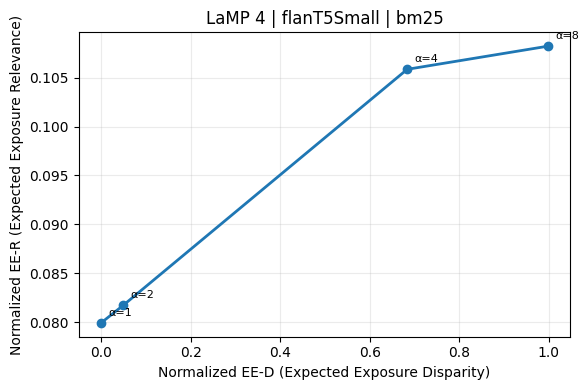

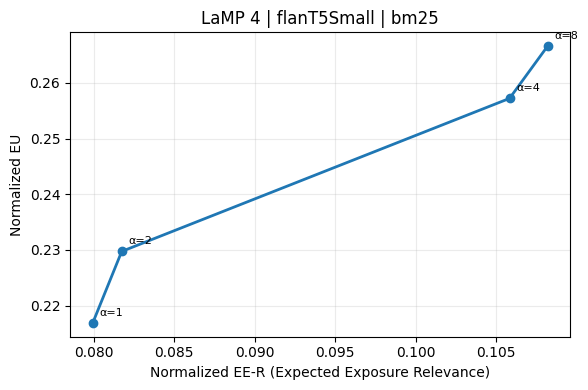

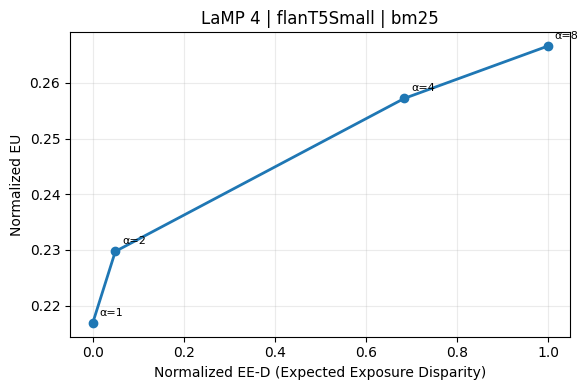


Saved summary: experiment_results/flanT5Small/lamp4/bm25/summary_lamp4_minimal.csv


In [ ]:
# ===== Aggregate normalized metrics + required plots only =====
print(f"\nLoading normalized LaMP{LAMP_NUM} results for {RETRIEVER}...")

rows = []
results_dir = REPO_ROOT / 'experiment_results' / GENERATOR_NAME / f'lamp{LAMP_NUM}' / RETRIEVER

for alpha in ALPHAS:
    fp = results_dir / f'alpha_{alpha}_normalized.json'
    if not fp.exists():
        print(f"Missing normalized file: {fp.name}")
        continue

    with open(fp, 'r', encoding='utf-8') as f:
        d = json.load(f)

    first_qid = next(iter(d.keys()))
    metric_name = next(iter(d[first_qid]['EU'].keys()))

    # EE metrics normalized by expected_exposure (theoretical bounds)
    # EU normalized by normalize_eu.py (max utility across runs)
    ee_d = [v['EE']['disparity'] for v in d.values()]
    ee_r = [v['EE']['relevance'] for v in d.values()]
    eu = [v['EU'][metric_name] for v in d.values()]

    rows.append({
        'alpha': alpha,
        'metric': metric_name,
        'EE_D_mean': float(pd.Series(ee_d).mean()),
        'EE_D_std': float(pd.Series(ee_d).std()),
        'EE_R_mean': float(pd.Series(ee_r).mean()),
        'EE_R_std': float(pd.Series(ee_r).std()),
        'EU_mean': float(pd.Series(eu).mean()),
        'EU_std': float(pd.Series(eu).std()),
        'query_count': len(d),
    })

if not rows:
    print('No normalized results found. Run cells 4-8 first.')
else:
    summary = pd.DataFrame(rows).sort_values('alpha')
    print('\nSummary (LaMP-4):')
    print(summary.to_string(index=False))
    display(summary)

    # 1) normalized EE-R vs normalized EE-D
    plt.figure(figsize=(6, 4))
    plt.plot(summary['EE_D_mean'], summary['EE_R_mean'], marker='o', linewidth=2)
    for _, r in summary.iterrows():
        plt.annotate(f"α={int(r['alpha'])}", (r['EE_D_mean'], r['EE_R_mean']), fontsize=8, xytext=(5, 5), textcoords='offset points')
    plt.title(f'LaMP {LAMP_NUM} | {GENERATOR_NAME} | {RETRIEVER}')
    plt.xlabel('Normalized EE-D (Expected Exposure Disparity)')
    plt.ylabel('Normalized EE-R (Expected Exposure Relevance)')
    plt.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()

    # 2) normalized EU vs normalized EE-R
    plt.figure(figsize=(6, 4))
    plt.plot(summary['EE_R_mean'], summary['EU_mean'], marker='o', linewidth=2)
    for _, r in summary.iterrows():
        plt.annotate(f"α={int(r['alpha'])}", (r['EE_R_mean'], r['EU_mean']), fontsize=8, xytext=(5, 5), textcoords='offset points')
    plt.title(f'LaMP {LAMP_NUM} | {GENERATOR_NAME} | {RETRIEVER}')
    plt.xlabel('Normalized EE-R (Expected Exposure Relevance)')
    plt.ylabel('Normalized EU')
    plt.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()

    # 3) normalized EU vs normalized EE-D
    plt.figure(figsize=(6, 4))
    plt.plot(summary['EE_D_mean'], summary['EU_mean'], marker='o', linewidth=2)
    for _, r in summary.iterrows():
        plt.annotate(f"α={int(r['alpha'])}", (r['EE_D_mean'], r['EU_mean']), fontsize=8, xytext=(5, 5), textcoords='offset points')
    plt.title(f'LaMP {LAMP_NUM} | {GENERATOR_NAME} | {RETRIEVER}')
    plt.xlabel('Normalized EE-D (Expected Exposure Disparity)')
    plt.ylabel('Normalized EU')
    plt.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()

    out_csv = REPO_ROOT / 'experiment_results' / GENERATOR_NAME / f'lamp{LAMP_NUM}' / RETRIEVER / 'summary_lamp4_minimal.csv'
    out_csv.parent.mkdir(parents=True, exist_ok=True)
    summary.to_csv(out_csv, index=False)
    print(f"\nSaved summary: {out_csv.relative_to(REPO_ROOT)}")


## Understanding the Normalization

**EE metrics (EE-D, EE-R) normalization:**
- Normalized **during experiments** by the expected_exposure library
- Uses theoretical bounds based on user model parameters (k, m, relevance levels)
- Formula: `(value - lowerBound) / (upperBound - lowerBound)`
- For BM25, typical EE-R range: 0.25-0.4

**EU (Expected Utility) normalization:**
- Normalized **after all experiments complete** by normalize_eu.py
- Uses empirical max from gold retriever + best across all alphas
- Formula: `EU / max(gold_max_utility, model_max_utility_across_alphas)`
- Represents percentage of optimal utility achieved